VARIANCE DECOMPOSITION ASSUMPTION CHECKS

[WARNING] Assumption Violated: Experimental Noise < Validation Noise
  -> detail: Exp(0.033650) < Val(0.042789) | Diff: -0.009139
------------------------------------------------------------
[PASSED] Experimental Traits >= Validation Traits for all features.

ABSOLUTE VARIANCE AND SIGNAL ESTIMATES

             Feature  Signal_Exp       DT       DN       HT       HN
              detail    0.003550 0.000000 0.042789 0.025220 0.000000
    r_directionality    0.005715 0.000000 0.007437 0.013326 0.047993
theta_directionality    0.005371 0.000000 0.005960 0.011847 0.050321
          brightness    0.002030 0.000000 0.010382 0.010790 0.012004
            contrast    0.000712 0.000000 0.002496 0.005026 0.004537

PROPORTIONAL DECOMPOSITION (% OF MODELED VARIANCE)

             Feature  Signal_Exp_prop  DT_prop  DN_prop  HT_prop  HN_prop
              detail            4.96%    0.00%   59.80%   35.24%    0.00%
    r_directionality            7.67%    0.

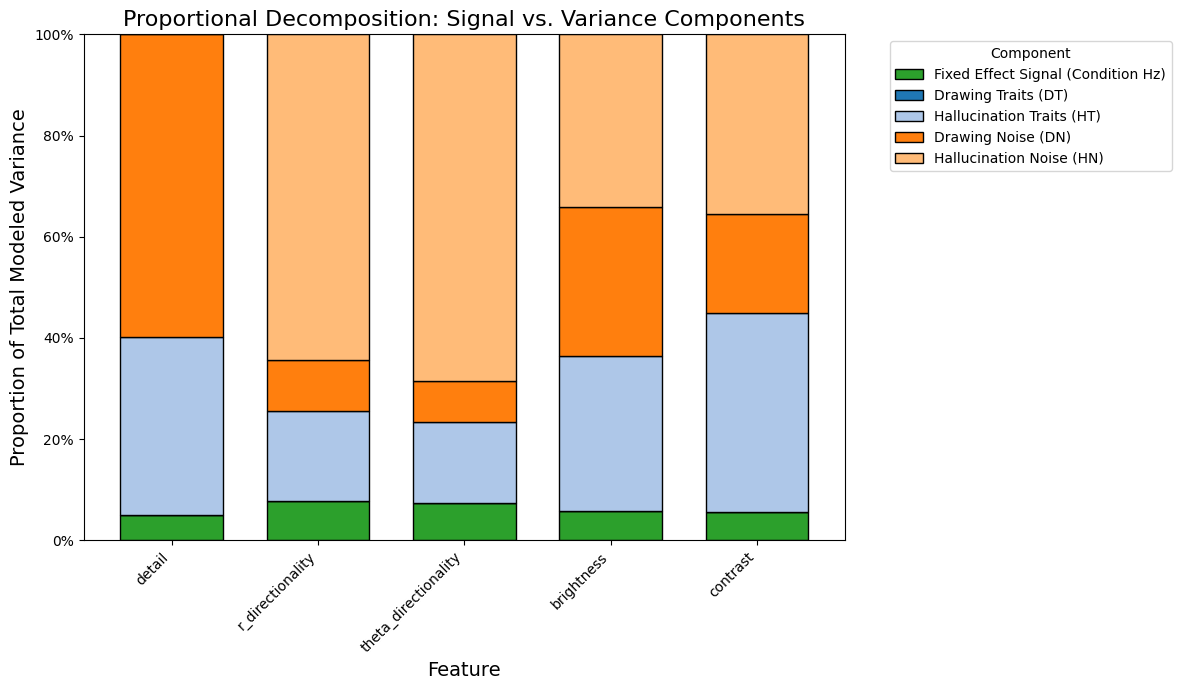

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Set pandas display options for verbose output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# 1. Load the comprehensive results
df_val = pd.read_csv("../015_tables/validation_results_full.csv")
df_exp = pd.read_csv("../015_tables/experimental_results_full.csv")

df_combined = pd.merge(df_val, df_exp, on='Feature', suffixes=('_val', '_exp'))

# 2. Assumption Checks & Verbose Logging
print("============================================================")
print("VARIANCE DECOMPOSITION ASSUMPTION CHECKS")
print("============================================================\n")

df_combined['Noise_Diff'] = df_combined['DN_plus_HN'] - df_combined['DN']
df_combined['Trait_Diff'] = df_combined['DT_plus_HT'] - df_combined['DT']

# Check Noise Assumption (DN_exp >= DN_val)
failed_noise = df_combined[df_combined['Noise_Diff'] < 0]
if not failed_noise.empty:
    print("[WARNING] Assumption Violated: Experimental Noise < Validation Noise")
    for _, row in failed_noise.iterrows():
        print(f"  -> {row['Feature']}: Exp({row['DN_plus_HN']:.6f}) < Val({row['DN']:.6f}) | Diff: {row['Noise_Diff']:.6f}")
else:
    print("[PASSED] Experimental Noise >= Validation Noise for all features.")

print("-" * 60)

# Check Trait Assumption (DT_exp >= DT_val)
failed_trait = df_combined[df_combined['Trait_Diff'] < 0]
if not failed_trait.empty:
    print("[WARNING] Assumption Violated: Experimental Traits < Validation Traits")
    for _, row in failed_trait.iterrows():
        print(f"  -> {row['Feature']}: Exp({row['DT_plus_HT']:.6f}) < Val({row['DT']:.6f}) | Diff: {row['Trait_Diff']:.6f}")
else:
    print("[PASSED] Experimental Traits >= Validation Traits for all features.")

print("\n============================================================")
print("ABSOLUTE VARIANCE AND SIGNAL ESTIMATES")
print("============================================================\n")

# 3. Extract Variance Differences (with clipping for assumption violations)
df_combined['HT'] = df_combined['Trait_Diff'].clip(lower=0)
df_combined['HN'] = df_combined['Noise_Diff'].clip(lower=0)

components = ['Signal_Exp', 'DT', 'DN', 'HT', 'HN']
df_abs = df_combined[['Feature'] + components].copy()
print(df_abs.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

print("\n============================================================")
print("PROPORTIONAL DECOMPOSITION (% OF MODELED VARIANCE)")
print("============================================================\n")

# 4. Convert to Proportions (Ratios scaling to 1)
df_variances = df_abs.copy()
df_variances['Total_Var'] = df_variances[components].sum(axis=1)

for col in components:
    df_variances[f'{col}_prop'] = df_variances[col] / df_variances['Total_Var']

df_prop_print = df_variances[['Feature'] + [f"{c}_prop" for c in components]].copy()
print(df_prop_print.to_string(index=False, float_format=lambda x: f"{x*100:.2f}%"))

# Save data
os.makedirs("../015_tables", exist_ok=True)
df_variances.to_csv("../015_tables/variance_decomposition_full.csv", index=False)
print("\n[INFO] Full variance table saved to ../015_tables/variance_decomposition_full.csv")

# 5. Plot 100% Stacked Bar Chart
df_plot = df_variances[['Feature', 'Signal_Exp_prop', 'DT_prop', 'HT_prop', 'DN_prop', 'HN_prop']].set_index('Feature')
fig, ax = plt.subplots(figsize=(12, 7))

# Distinct colors: Signal (Green), Between-Subject (Blues), Within-Subject (Oranges)
colors = ['#2ca02c', '#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78'] 

df_plot.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', width=0.7)

ax.set_title('Proportional Decomposition: Signal vs. Variance Components', fontsize=16)
ax.set_ylabel('Proportion of Total Modeled Variance', fontsize=14)
ax.set_xlabel('Feature', fontsize=14)
ax.set_ylim(0, 1)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.legend(['Fixed Effect Signal (Condition Hz)', 'Drawing Traits (DT)', 'Hallucination Traits (HT)', 'Drawing Noise (DN)', 'Hallucination Noise (HN)'], 
          title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
os.makedirs("../020_visualizations", exist_ok=True)
plt.savefig("../020_visualizations/signal_vs_variance_ratio.png", dpi=300, bbox_inches='tight')
plt.show()